In [6]:
import pandas as pd

df = pd.read_csv(r"C:\Users\admin\OneDrive\Desktop\Shraddha imp\Telco-Customer-Churn.csv")

In [7]:
df.head()

,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,...,device_protection,tech_support,streaming_tv,streaming_movies,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df["total_charges"] = pd.to_numeric(df["total_charges"], errors="coerce")
df = df.dropna()                                 

In [9]:
df["churn"] = df["churn"].map({"Yes":1, "No":0})

In [10]:
df["CLV"] = df["monthly_charges"] * df["tenure"]

In [11]:
def tenure_group(x):
    if x <= 12:
        return "New"
    elif x <= 36:
        return "Growing"
    else:
        return "Loyal"

df["Tenure_Group"] = df["tenure"].apply(tenure_group)

In [12]:
df_ml = pd.get_dummies(df, drop_first=True)

In [13]:
x = df_ml.drop("churn", axis=1)
y = df_ml["churn"]

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [15]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()

model.fit(x_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [16]:
from sklearn.metrics import accuracy_score

pred = model.predict(x_test)

accuracy_score(y_test, pred)

0.7882018479033405

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.82      0.92      0.86      1033
           1       0.65      0.43      0.52       374

    accuracy                           0.79      1407
   macro avg       0.74      0.67      0.69      1407
weighted avg       0.77      0.79      0.77      1407



<Axes: >

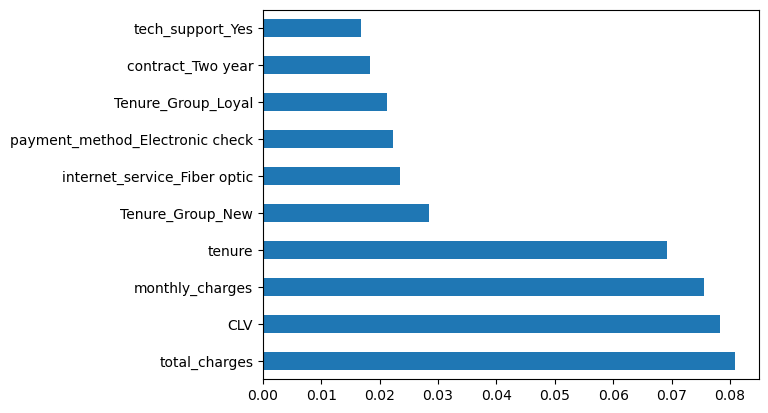

In [23]:
feat_importance = pd.Series(model.feature_importances_, index=x.columns)
feat_importance.nlargest(10).plot(kind='barh')

In [17]:
df["churn_probability"] = model.predict_proba(x)[:,1]

In [18]:
df["revenue_at_risk"] = df["monthly_charges"] * df["churn_probability"]

In [20]:
def risk_segment(x):

    if x > 0.7:
        return "High Risk"
    elif x > 0.4:
        return "Medium Risk"
    else: 
        return "Low Risk"

df["Risk_Segment"] = df["churn_probability"].apply(risk_segment)

In [37]:
dashboard_df = df[[
    "customer_id",
    "tenure",
    "monthly_charges",
    "total_charges",
    "contract",
    "internet_service",
    "payment_method",
    "CLV",
    "Tenure_Group",
    "churn",
    "churn_probability",
    "revenue_at_risk",
    "Risk_Segment"
]]

dashboard_df.to_csv("AI_churn_dashboard_data.csv", index=False)

In [38]:
print(df.columns.tolist())

['customer_id', 'gender', 'senior_citizen', 'partner', 'dependents', 'tenure', 'phone_service', 'multiple_lines', 'internet_service', 'online_security', 'online_backup', 'device_protection', 'tech_support', 'streaming_tv', 'streaming_movies', 'contract', 'paperless_billing', 'payment_method', 'monthly_charges', 'total_charges', 'churn', 'CLV', 'churn_probability', 'revenue_at_risk', 'Tenure_Group', 'Risk_Segment']
